The following notebook assumes that the `rec_hits` csv file exists and was generated by `root2csv` with the `-l` and `-g` flags.

In [1]:
import pandas as pd
import numpy  as np
import math

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_style("darkgrid")

In [ ]:
# ~~+ Global 2D coordinates. +~~~
bg  = "#DA9EAA"
pal = sns.dark_palette("#B92544", as_cmap = True)

# Plot entire dRICH cell map in the EIC global x, y coordinates.
def global2d_plotcells(df):
    sns.scatterplot(
        x = df["gx"], y = df["gy"],
        s = .4, edgecolor = None, color = bg#, hue = df["pdu"]#, legend = "full"
    )

# Plot hits from event `ei` in the EIC global x, y coordinates.
def global2d_plothits(df, ei,c="blue"):
    df = df[df["event"] == ei]
    sns.scatterplot(
        x = df["gx"], y = df["gy"],
        s = 10, color=c# hue = df["pindex"],
    )

def global2d_plothits_tag(df, tf, ei):
    df = df[df["event"] == ei]
    tf = tf[tf["event"] == ei]
    x_a=[]
    y_a=[]
    hue_a=[]
    print("START")
    for idx, row in df.iterrows():
        x_a.append(row["gx"])
        y_a.append(row["gy"])
        if(row["pindex"]==0):
            #print("NOISE")
            hue_a.append(0)
        else:
            for idx_t, row_t in tf.iterrows():
                if(row["pindex"]==row_t["pindex"]):
                    #print("MATCH!")
                    hue_a.append(row_t["pdg"])
                    #print(row_t["pdg"])
                    break

    print(np.asarray(x_a).shape)
    print(np.asarray(y_a).shape)
    print(np.asarray(hue_a).shape)

    sns.scatterplot(
        x = x_a, y = y_a,
        s = 10, hue = hue_a, palette =  sns.color_palette()
    )

def global2d_plothits_timing(df, ei):
    df = df[df["event"] == ei]
    hue_t=[]
    max_time = max(df["time"])
    print(max_time)
    for idx, row in df.iterrows():
        hue_t.append(round(row["time"]))

    sns.scatterplot(
        x = df["gx"], y = df["gy"],
        s = 10, hue = hue_t, palette =  sns.color_palette()
    )

In [ ]:
help(sns.scatterplot)

Help on function scatterplot in module seaborn.relational:

scatterplot(data=None, *, x=None, y=None, hue=None, size=None, style=None, palette=None, hue_order=None, hue_norm=None, sizes=None, size_order=None, size_norm=None, markers=True, style_order=None, legend='auto', ax=None, **kwargs)
    Draw a scatter plot with possibility of several semantic groupings.

    The relationship between `x` and `y` can be shown for different subsets
    of the data using the `hue`, `size`, and `style` parameters. These
    parameters control what visual semantics are used to identify the different
    subsets. It is possible to show up to three dimensions independently by
    using all three semantic types, but this style of plot can be hard to
    interpret and is often ineffective. Using redundant semantics (i.e. both
    `hue` and `style` for the same variable) can be helpful for making
    graphics more accessible.

    See the :ref:`tutorial <relational_tutorial>` for more information.

    The

In [ ]:
# ~~+ Local 2D coordinates. +~~~
# Build cell matrix for sector `sec` in its local coordinate system.
def local_buildmatrix(df, sec):
    df = df[df["sector"] == sec]

    # Get size and generate matrix.
    #matrix_dims = (df["lx"].max()+1, df["ly"].max()+1)
    rot_x_max = df["lx"].max()*math.cos(-30) - df["ly"].max()*math.sin(-30)
    rot_y_max = df["lx"].max()*math.sin(-30) + df["ly"].max()*math.cos(-30)

   # print(rot_x_max)
   # print(rot_y_max)
    matrix_dims = (df["lx"].max()+1, df["ly"].max()+1)

    cell_matrix = np.zeros((matrix_dims[0], matrix_dims[1]))
    #print("Matrix dims: [%d,%d]" % (matrix_dims[0], matrix_dims[1]))

    # Iterate cells.
    for idx, row in df.iterrows():
        x, y = int(row["lx"]), int(row["ly"])

        rot_x = x*math.cos(0) - y*math.sin(0)
        rot_y = x*math.sin(0) + y*math.cos(0)
        #x, y = round(row["gx"])+xmin, round(row["gy"])+ymin

        # Check if two cells have the same position.
        # if (cell_matrix[x][y] > .1):
        #     print("Error: Duplicate input in cell [%d,%d]" % (x, y))

        # Fill matrix with the base value 100. Deposited charge is usually over
        #     200, so this allows for easy differentiation.
        cell_matrix[round(rot_x)][round(rot_y)] = 100

    return cell_matrix

# Add deposited charge in event `ei` to cell matrix for sector `sec` in its lo-
#     cal coordinate system.
def local_addcharge(matrix, df, ei, sec):
    df = df[(df["event"] == ei) & (df["sector"] == sec)]

    for idx, row in df.iterrows():
        matrix[int(row["lx"])][int(row["ly"])] += row["charge"]*2*5
        #matrix[round(row["gx"])][round(row["gy"])] += row["charge"]


def global_buildmatrix(df,localmatrix):

    global_matrix = np.zeros((355, 355))
    for sec in range(0,6):
        print(sec)
        file = df[df["sector"] == sec]

        #gx_min = -177
        #gy_min = -177
        #gx_max = +177
        #gy_max = +177
        # Get size and generate matrix.
        #matrix_dims = (int((-1*gx_min)+gx_max)+1, int((-1*gy_min)+gy_max)+1)

        #global_matrix = np.zeros((matrix_dims[0], matrix_dims[1]))
    #print("Matrix dims: [%d,%d]" % (matrix_dims[0], matrix_dims[1]))

    # Iterate cells.
        for idx, row in file.iterrows():
            x, y = int(row["gx"]), int(row["gy"])
            lx, ly =  int(row["lx"]), int(row["ly"])
           # print(lx)
           # print(ly)

        # Check if two cells have the same position.
        # if (cell_matrix[x][y] > .1):
        #     print("Error: Duplicate input in cell [%d,%d]" % (x, y))

        # Fill matrix with the base value 100. Deposited charge is usually over
        #     200, so this allows for easy differentiation.
            global_matrix[(x+177)][(y+177)] = localmatrix[sec][lx][ly]

    return global_matrix


In [ ]:
def matrix_segmentation(matrix,xmax,ymax):
    sipm_count = [0, 0, 0, 0, 0]

    for x in range(0,55):
        for y in range(31,65):
            if(y>=-0.891*x+81 and matrix[y][x]!=0):
                matrix[y][x]+= 200
                sipm_count[0]+=1

    for x in range(55,xmax):
        for y in range(31,65):
            if(y>=+0.891*x-17 and matrix[y][x]!=0):
                matrix[y][x]+= 200
                sipm_count[0]+=1

    for x in range(0,55):
        for y in range(31,ymax):
            if(y<-0.891*x+81 and matrix[y][x]!=0):
                matrix[y][x]+= 300
                sipm_count[1]+=1
    for x in range(55,xmax):
        for y in range(31,ymax):
            if(y<+0.891*x-17 and matrix[y][x]!=0):
                matrix[y][x]+= 400
                sipm_count[2]+=1

    for x in range(0,55):
        for y in range(0,31):
            if(matrix[y][x]!=0):
                matrix[y][x]+= 500
                sipm_count[3]+=1

    for x in range(55,xmax):
        for y in range(0,31):
            if(matrix[y][x]!=0):
                matrix[y][x]+= 600
                sipm_count[4]+=1
    print(sipm_count)

    sipm_proof = 6720 -(sipm_count[0]+sipm_count[1]+sipm_count[2]+sipm_count[3])
    print("List of sipm_count: \n")
    print(sipm_proof)

def matrix_segmentation_local(matrix,x_center,y_center,c1,c2):
    sipm_count = [0, 0, 0, 0, 0]
    lx_sector_lists = [[],[],[],[],[]]
    ly_sector_lists = [[],[],[],[],[]]


    m1 = (c1-y_center)/x_center
    m2 = (c2-y_center)/x_center


    for x in range(0,413):
        for y in range(y_center,371):
            if( y>=-m1*x+c1 and matrix[y][x]!=0):
                matrix[y][x]+= 200
                sipm_count[0]+=1
                lx_sector_lists[0].append(x)
                ly_sector_lists[0].append(y)

    for x in range(0,413):
        for y in range(y_center,371):
            if( y<=-m1*x+c1 and matrix[y][x]!=0):
                matrix[y][x]+= 400
                sipm_count[1]+=1
                lx_sector_lists[1].append(x)
                ly_sector_lists[1].append(y)

    for x in range(0,x_center):
        for y in range(0,189):
            if(matrix[y][x]!=0):
                matrix[y][x]+= 600
                sipm_count[2]+=1
                lx_sector_lists[2].append(x)
                ly_sector_lists[2].append(y)

    for x in range(x_center,455):
        for y in range(0,y_center):
            if(y<=-m2*x+c2 and matrix[y][x]!=0):
                matrix[y][x]+= 800
                sipm_count[3]+=1
                lx_sector_lists[3].append(x)
                ly_sector_lists[3].append(y)

    for x in range(x_center,455):
        for y in range(0,y_center):
            if(y>=-m2*x+c2 and matrix[y][x]!=0):
                matrix[y][x]+= 1000
                sipm_count[4]+=1
                lx_sector_lists[4].append(x)
                ly_sector_lists[4].append(y)

    #print("List of sipm_count: \n")
    #print(sipm_count)

    sipm_proof = 6720 -(sipm_count[0]+sipm_count[1]+sipm_count[2]+sipm_count[3])

    return lx_sector_lists,ly_sector_lists


def grid_def(lx_sector_lists, ly_sector_lists, size):
    grid = 0
    x_step, y_step = 0, 0
    #size = 64


    grid_matrix = np.zeros((5,size, size))
    grid_list_subsector = []
    lx_max = []
    ly_max = []
    lx_min = []
    ly_min = []

    for n in range(0,5):
        grid_list_subsector.append([])
        lx_max.append(max(lx_sector_lists[n]))
        ly_max.append(max(ly_sector_lists[n]))
        lx_min.append(min(lx_sector_lists[n]))
        ly_min.append(min(ly_sector_lists[n]))
        for gd_x in range(0,size):
            grid_list_subsector[n].append([])
            for gd_y in range(0,size):
                grid_list_subsector[n][gd_x].append([])


    for n in range(0,5):
        for i in range(0,len(lx_sector_lists[n])):
            x = lx_sector_lists[n][i]-lx_min[n]
            y = ly_sector_lists[n][i]-ly_min[n]
            if([x,y]==[x_step,y_step]):
                continue
            else:
                x_step=x
                y_step=y
            for gd_x in range(0,size):
                for gd_y in range(0,size):
                    if(x<((gd_x+1)/size)*(lx_max[n]-lx_min[n]) and x>(gd_x/size)*(lx_max[n]-lx_min[n]) and y<((gd_y+1)/size)*(ly_max[n]-ly_min[n]) and y>(gd_y/size)*(ly_max[n]-ly_min[n])):
                            #matrix[y][x]+=500*(gd_x*32+gd_y*8)#(gd_x*8+gd_y+1)*100
                            grid_list_subsector[n][gd_x][gd_y].append([lx_sector_lists[n][i],ly_sector_lists[n][i]])
                            grid_matrix[n][gd_x][gd_y]+= 1



    return grid_matrix, grid_list_subsector





In [ ]:
def grid_ev(lx_sector_lists, ly_sector_lists, size, df, ei,sec):
    grid = 0
    x_step, y_step = 0, 0

    grid_matrix = np.zeros((5,size, size))
    grid_lists = [[],[],[],[],[]]

    lx_max = []
    ly_max = []
    lx_min = []
    ly_min = []

    ev_x_lists = []
    ev_y_lists = []

    for n in range(0,5):
        lx_max.append(max(lx_sector_lists[n]))
        ly_max.append(max(ly_sector_lists[n]))
        lx_min.append(min(lx_sector_lists[n]))
        ly_min.append(min(ly_sector_lists[n]))

    #for n in range(0,6):
    df = df[(df["event"] == ei) & (df["sector"] == sec)]
    for idx, row in df.iterrows():
            ev_x_lists.append(int(row["lx"]))
            ev_y_lists.append(int(row["ly"]))



    for n in range(0,5):
        for i in range(0,len(lx_sector_lists[n])):
            x0 = lx_sector_lists[n][i]
            y0 = ly_sector_lists[n][i]
            x = x0 - lx_min[n]
            y = y0 - ly_min[n]
            if([x,y]==[x_step,y_step]):
                continue
            else:
                x_step=x
                y_step=y
            if(ev_x_lists.count(x0)>0 and ev_y_lists.count(y0)>0):
                #print(x,y)
                for gd_x in range(0,size):
                    for gd_y in range(0,size):
                        if(x<((gd_x+1)/size)*(lx_max[n]-lx_min[n]) and x>(gd_x/size)*(lx_max[n]-lx_min[n]) and y<((gd_y+1)/size)*(ly_max[n]-ly_min[n]) and y>(gd_y/size)*(ly_max[n]-ly_min[n])):
                            grid_lists[n].append([x0,y0])
                            #matrix[y][x]+=500*(gd_x*32+gd_y*8)#(gd_x*8+gd_y+1)*100
                            grid_matrix[n][gd_x][gd_y]+= 1



    return grid_matrix,grid_lists

In [ ]:
!ls

Bkg_1SignalPer2usframe_2601
Bkg_new
cellmap.csv
cellmap_visualizer.ipynb
csv_reco
cut_data.ipynb
dataset_ALCOR_fromcampaign.ipynb
dataset_ALCOR_fromcampaign_timingaware.ipynb
hgq2_requirements.txt
hgq_da4ml.ipynb
hgq_env
hw_dam_prova_0
hw_dam_prova_1
hw_dam_prova_10
hw_dam_prova_11
hw_dam_prova_12
hw_dam_prova_13
hw_dam_prova_14
hw_dam_prova_15
hw_dam_prova_16
hw_dam_prova_17
hw_dam_prova_18
hw_dam_prova_19
hw_dam_prova_2
hw_dam_prova_20
hw_dam_prova_21
hw_dam_prova_22
hw_dam_prova_23
hw_dam_prova_24
hw_dam_prova_25
hw_dam_prova_26
hw_dam_prova_27
hw_dam_prova_28
hw_dam_prova_29
hw_dam_prova_3
hw_dam_prova_4
hw_dam_prova_5
hw_dam_prova_6
hw_dam_prova_7
hw_dam_prova_8
hw_dam_prova_9
hw_last_model_prova_5
hw_sector_prova_0
hw_sector_prova_1
hw_sector_prova_2
hw_sector_prova_3
hw_sector_prova_4
hw_sector_prova_5
intermediate_output_txt
noise_data_150kHz_old.npy
noise_data_150kHz_timingaware.npy
noise_data_300kHz_old.npy
noise_data.npy
positional_threshold.ipynb
Python-3.12.12
Python-3.12.

In [ ]:
# Get data.
df_cellmap = pd.read_csv("cellmap.csv",  sep = ',')
#df_rec_last     = pd.read_csv("Bkg_1SignalPer2usframe_2601/rec_hits_0002.csv", sep = ',')
df_rec_last     = pd.read_csv("Bkg_new/rec_new_0002.csv", sep = ',')
df_sim_last     = pd.read_csv("Bkg_1SignalPer2usframe_2601/sim_parts_0002.csv", sep = ',')
df_noise        = pd.read_csv("csv_reco/noise_reco_0_150kHz_10ns.csv", sep = ',')

In [ ]:
import numpy as np

#df_time_noise = [df_rec["event"] == 100]
df_time_events = df_rec_last#[df_rec_1["event"] == 100]
df_time_noise = df_noise#[df_rec["event"] <= 19]

print(df_time_noise)
print(df_sim_last)

        event           cell_id  sector      time  charge  pindex          gx  \
0           0   844455020275832       0  5.181827     280       0  121.474954   
1           0  1407387768664184       0  5.111663     280       0  122.094262   
2           0  1970350606997624       0  2.380051     280       0  136.268379   
3           0  1688862745391224       0  4.852079     280       0  143.563420   
4           0  1970342033854584       0  0.259822     280       0  105.268086   
...       ...               ...     ...       ...     ...     ...         ...   
483713    999  1407374883724664       5  6.130009     280       0  135.272499   
483714    999  1125904210388344       5  2.578111     280       0  112.355299   
483715    999        4320324984       5  2.709662     280       0  111.226998   
483716    999  1125899932206456       5  2.129886     280       0  148.780464   
483717    999       17188457848       5  6.694513     280       0  144.475889   

                gy         

In [ ]:
import os

# cartella output per i plot
OUTDIR = "report_plots_histo"
os.makedirs(OUTDIR, exist_ok=True)

In [ ]:
import os
import pandas as pd
import numpy as np
import time

nfiles = 800
df_rec_signal_list = []
df_index = 0
new_file_init = True

start = time.perf_counter()

for f in range(nfiles):
    print(f"SIGNAL FILE n.{f}")

    #file_string = f"Bkg_1SignalPer2usframe_2601/rec_hits_{f+1:04d}.csv"
    file_string = f"Bkg_new/rec_new_{f+1:04d}.csv"

    if not os.path.exists(file_string):
        print(file_string + " skipped!")
        continue

    # Leggi CSV
    df_rec_signal = pd.read_csv(file_string, sep=',')

    # Salta DataFrame vuoti o senza colonna "event"
    if df_rec_signal.empty or "event" not in df_rec_signal.columns:
        continue

    # Riallinea eventi locali partendo da 0
    df_rec_signal["event"] = df_rec_signal.groupby("event", sort=False).ngroup()

    # Converte a intero per sicurezza
    df_rec_signal["event"] = df_rec_signal["event"].astype(int)

    nevents = df_rec_signal["event"].max()

    if new_file_init:
        # Split se supera 999
        if nevents > 999:
            df1 = df_rec_signal[df_rec_signal["event"] <= 999].copy()
            df2 = df_rec_signal[df_rec_signal["event"] > 999].copy()

            if not df2.empty:
                df2["event"] = (df2["event"] - df2["event"].min()) % 1000
                df2["event"] = df2["event"].astype(int)

            df_rec_signal_list.append(df1)
            df_index += 1
            df_rec_signal_list.append(df2)
        else:
            df_rec_signal_list.append(df_rec_signal)
        new_file_init = False
    else:
        # Offset globale rispetto al precedente, modulo 1000 per wrap
        df_previous = df_rec_signal_list[df_index]
        prev_max = df_previous["event"].max() if not df_previous.empty else -1
        df_rec_signal["event"] = (df_rec_signal["event"] + prev_max + 1)# % 1000
        df_rec_signal["event"] = df_rec_signal["event"].astype(int)

        # Concatenate temporanea
        df_conc = pd.concat([df_previous, df_rec_signal], ignore_index=True)
        nev = df_conc["event"].max()

        if nev > 999:
            df1 = df_conc[df_conc["event"] <= 999].copy()
            df2 = df_conc[df_conc["event"] > 999].copy()

            if not df2.empty:
                df2["event"] = (df2["event"] - df2["event"].min()) % 1000
                df2["event"] = df2["event"].astype(int)

            df_rec_signal_list[df_index] = df1
            df_index += 1
            df_rec_signal_list.append(df2)
            new_file_init = False
        else:
            df_rec_signal_list[df_index] = df_conc
            if nev == 999:
                new_file_init = True

end = time.perf_counter()
print(f"Tempo totale merging SIG+NOISE: {end - start:.4f}s")

SIGNAL FILE n.0
SIGNAL FILE n.1
SIGNAL FILE n.2
SIGNAL FILE n.3
SIGNAL FILE n.4
Bkg_new/rec_new_0005.csv skipped!
SIGNAL FILE n.5
SIGNAL FILE n.6
SIGNAL FILE n.7
SIGNAL FILE n.8
SIGNAL FILE n.9
SIGNAL FILE n.10
SIGNAL FILE n.11
SIGNAL FILE n.12
SIGNAL FILE n.13
SIGNAL FILE n.14
SIGNAL FILE n.15
Bkg_new/rec_new_0016.csv skipped!
SIGNAL FILE n.16
SIGNAL FILE n.17
SIGNAL FILE n.18
Bkg_new/rec_new_0019.csv skipped!
SIGNAL FILE n.19
SIGNAL FILE n.20
SIGNAL FILE n.21
SIGNAL FILE n.22
SIGNAL FILE n.23
Bkg_new/rec_new_0024.csv skipped!
SIGNAL FILE n.24
SIGNAL FILE n.25
SIGNAL FILE n.26
Bkg_new/rec_new_0027.csv skipped!
SIGNAL FILE n.27
SIGNAL FILE n.28
SIGNAL FILE n.29
SIGNAL FILE n.30
SIGNAL FILE n.31
SIGNAL FILE n.32
SIGNAL FILE n.33
SIGNAL FILE n.34
SIGNAL FILE n.35
Bkg_new/rec_new_0036.csv skipped!
SIGNAL FILE n.36
SIGNAL FILE n.37
SIGNAL FILE n.38
SIGNAL FILE n.39
SIGNAL FILE n.40
SIGNAL FILE n.41
SIGNAL FILE n.42
SIGNAL FILE n.43
SIGNAL FILE n.44
SIGNAL FILE n.45
Bkg_new/rec_new_0046.csv

In [ ]:
print(df_rec_signal_list[0][df_rec_signal_list[0]["event"]==41])

      event           cell_id  sector   time  charge  pindex          gx  \
4486     41   844424955701624       1  13317     274      25   -9.293674   
4487     41       12885279096       1  13318     271      25   -9.525026   
4488     41       12910444920       1  13318     299      25  -12.291670   
4489     41   562980026962296       1  13318     262      25   -1.844467   
4490     41  1125904202187128       1  13318     270      25  -10.747368   
4491     41  1125925676996984       1  13319     302      25   -2.693512   
4492     41  1407379187325304       1  13319     250      25   22.570488   
4493     41       30065121656       1  13319     252      25   -1.421225   
4494     41   562975731962232       1  13319     273      25  -10.139156   
4495     41   281492165378424       1  13319     302      25    7.824300   
4496     41  1407400670562680       1  13319     286      25   14.316350   
4497     41  1125912800447352       3  13321     272      25 -106.956528   
4498     41 

In [ ]:
import time
from time import perf_counter
sig_times = []

for ev in range(max(df_rec_signal_list[0]["event"])):
    ev=ev+1
    #print(ev)
    start = perf_counter()
    df = df_rec_signal_list[0][df_rec_signal_list[0]["event"]==ev]
    min_time = min(df["time"])
    # questo era quello originale 1/2                         time_col = ((df["time"]-min_time))/16)%20.32
    time_col = ((df["time"]-min_time))
    #time_col = (df["time"]/16)%20.32
    if (ev==1):
        sig_times = time_col
    else:
        df_previous = sig_times
        sig_times =  pd.concat([df_previous, time_col])
    end = perf_counter()
    if(ev%100 == 0):
        print(f"Tempo totale per eventp: {end - start:.4f}s")



Tempo totale per eventp: 0.0003s
Tempo totale per eventp: 0.0002s
Tempo totale per eventp: 0.0002s
Tempo totale per eventp: 0.0002s
Tempo totale per eventp: 0.0002s
Tempo totale per eventp: 0.0003s
Tempo totale per eventp: 0.0003s
Tempo totale per eventp: 0.0003s
Tempo totale per eventp: 0.0003s


50       0
51       0
52       1
53       1
54       1
        ..
86496    5
86497    5
86498    5
86499    5
86500    9
Name: time, Length: 86451, dtype: int64
0         6145
1         6145
2         6145
3         6145
4         6146
         ...  
86496    22379
86497    22379
86498    22379
86499    22379
86500    22383
Name: time, Length: 86501, dtype: int64
483718
86501
[ 0.    2.54  5.08  7.62 10.16]
Set di estremi dei bin utilizzati
[ 0.    2.54  5.08  7.62 10.16]
[120890. 121113. 120736. 120979.]
598.6608910891089
Integrale Signal: 86451.0
Integrale Noise: 483718.0
Salvato: report_plots_histo/histogram_dcr300kHz_Bin2.54ns.png


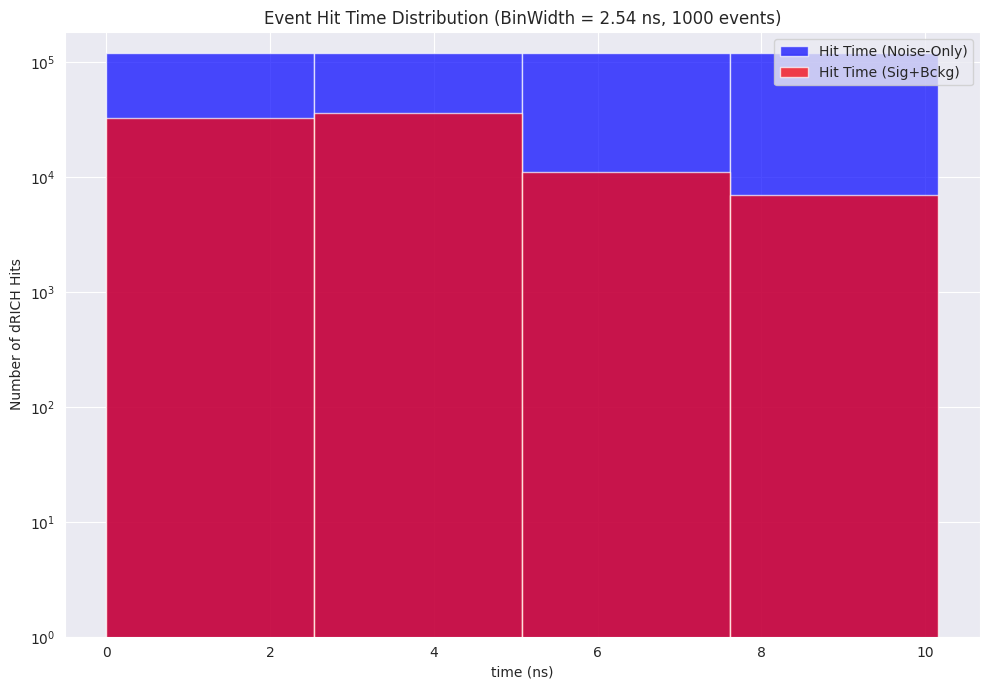

[ 0.    1.27  2.54  3.81  5.08  6.35  7.62  8.89 10.16]
Set di estremi dei bin utilizzati
[ 0.    1.27  2.54  3.81  5.08  6.35  7.62  8.89 10.16]
[60638. 60252. 60420. 60693. 60426. 60310. 60580. 60399.]
299.33044554455444
Integrale Signal: 86451.0
Integrale Noise: 483718.0
Salvato: report_plots_histo/histogram_dcr300kHz_Bin1.27ns.png


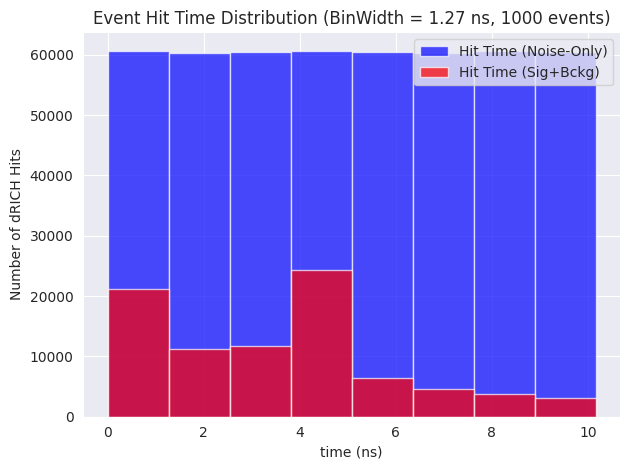

[ 0.     0.635  1.27   1.905  2.54   3.175  3.81   4.445  5.08   5.715
  6.35   6.985  7.62   8.255  8.89   9.525 10.16 ]
Set di estremi dei bin utilizzati
[ 0.     0.635  1.27   1.905  2.54   3.175  3.81   4.445  5.08   5.715
  6.35   6.985  7.62   8.255  8.89   9.525 10.16 ]
[30159. 30479. 30117. 30135. 30212. 30208. 30239. 30454. 30355. 30071.
 30276. 30034. 30409. 30171. 30049. 30350.]
149.66522277227722
Integrale Signal: 86451.0
Integrale Noise: 483718.0
Salvato: report_plots_histo/histogram_dcr300kHz_Bin0.635ns.png


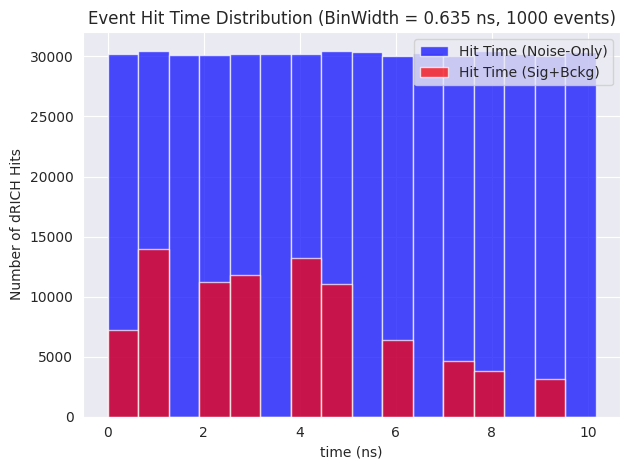

[ 0.      0.3175  0.635   0.9525  1.27    1.5875  1.905   2.2225  2.54
  2.8575  3.175   3.4925  3.81    4.1275  4.445   4.7625  5.08    5.3975
  5.715   6.0325  6.35    6.6675  6.985   7.3025  7.62    7.9375  8.255
  8.5725  8.89    9.2075  9.525   9.8425 10.16  ]
Set di estremi dei bin utilizzati
[ 0.      0.3175  0.635   0.9525  1.27    1.5875  1.905   2.2225  2.54
  2.8575  3.175   3.4925  3.81    4.1275  4.445   4.7625  5.08    5.3975
  5.715   6.0325  6.35    6.6675  6.985   7.3025  7.62    7.9375  8.255
  8.5725  8.89    9.2075  9.525   9.8425 10.16  ]
[15062. 15097. 15208. 15271. 15125. 14992. 14986. 15149. 15097. 15115.
 15031. 15177. 15046. 15193. 15393. 15061. 15210. 15145. 15137. 14934.
 15174. 15102. 14900. 15134. 15193. 15216. 15063. 15108. 15069. 14980.
 15184. 15166.]
74.83261138613861
Integrale Signal: 86451.0
Integrale Noise: 483718.0
Salvato: report_plots_histo/histogram_dcr300kHz_Bin0.3175ns.png


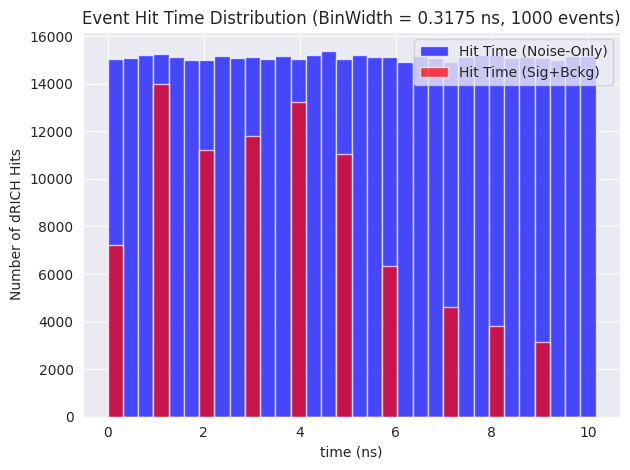

[ 0.       0.15875  0.3175   0.47625  0.635    0.79375  0.9525   1.11125
  1.27     1.42875  1.5875   1.74625  1.905    2.06375  2.2225   2.38125
  2.54     2.69875  2.8575   3.01625  3.175    3.33375  3.4925   3.65125
  3.81     3.96875  4.1275   4.28625  4.445    4.60375  4.7625   4.92125
  5.08     5.23875  5.3975   5.55625  5.715    5.87375  6.0325   6.19125
  6.35     6.50875  6.6675   6.82625  6.985    7.14375  7.3025   7.46125
  7.62     7.77875  7.9375   8.09625  8.255    8.41375  8.5725   8.73125
  8.89     9.04875  9.2075   9.36625  9.525    9.68375  9.8425  10.00125]
Set di estremi dei bin utilizzati
[ 0.       0.15875  0.3175   0.47625  0.635    0.79375  0.9525   1.11125
  1.27     1.42875  1.5875   1.74625  1.905    2.06375  2.2225   2.38125
  2.54     2.69875  2.8575   3.01625  3.175    3.33375  3.4925   3.65125
  3.81     3.96875  4.1275   4.28625  4.445    4.60375  4.7625   4.92125
  5.08     5.23875  5.3975   5.55625  5.715    5.87375  6.0325   6.19125
  6.35     6.508

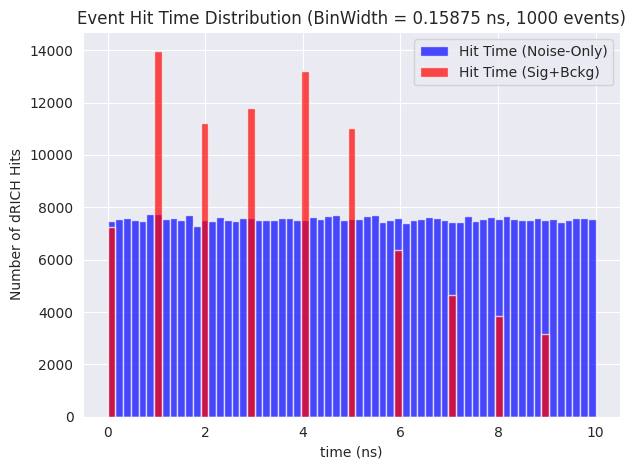

[ 0.        0.079375  0.15875   0.238125  0.3175    0.396875  0.47625
  0.555625  0.635     0.714375  0.79375   0.873125  0.9525    1.031875
  1.11125   1.190625  1.27      1.349375  1.42875   1.508125  1.5875
  1.666875  1.74625   1.825625  1.905     1.984375  2.06375   2.143125
  2.2225    2.301875  2.38125   2.460625  2.54      2.619375  2.69875
  2.778125  2.8575    2.936875  3.01625   3.095625  3.175     3.254375
  3.33375   3.413125  3.4925    3.571875  3.65125   3.730625  3.81
  3.889375  3.96875   4.048125  4.1275    4.206875  4.28625   4.365625
  4.445     4.524375  4.60375   4.683125  4.7625    4.841875  4.92125
  5.000625  5.08      5.159375  5.23875   5.318125  5.3975    5.476875
  5.55625   5.635625  5.715     5.794375  5.87375   5.953125  6.0325
  6.111875  6.19125   6.270625  6.35      6.429375  6.50875   6.588125
  6.6675    6.746875  6.82625   6.905625  6.985     7.064375  7.14375
  7.223125  7.3025    7.381875  7.46125   7.540625  7.62      7.699375
  7.77875   7.8581

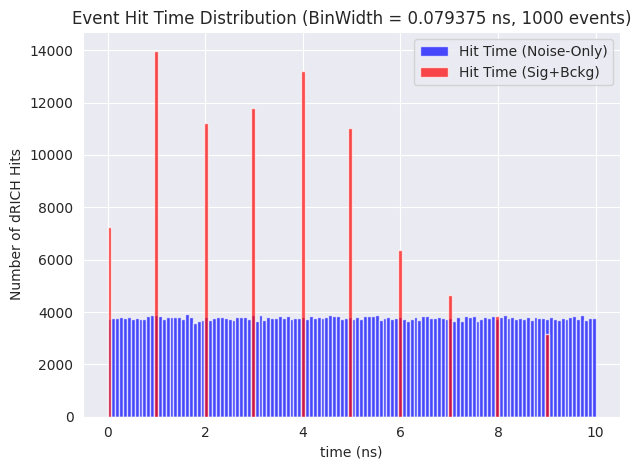

[ 0.         0.0396875  0.079375   0.1190625  0.15875    0.1984375
  0.238125   0.2778125  0.3175     0.3571875  0.396875   0.4365625
  0.47625    0.5159375  0.555625   0.5953125  0.635      0.6746875
  0.714375   0.7540625  0.79375    0.8334375  0.873125   0.9128125
  0.9525     0.9921875  1.031875   1.0715625  1.11125    1.1509375
  1.190625   1.2303125  1.27       1.3096875  1.349375   1.3890625
  1.42875    1.4684375  1.508125   1.5478125  1.5875     1.6271875
  1.666875   1.7065625  1.74625    1.7859375  1.825625   1.8653125
  1.905      1.9446875  1.984375   2.0240625  2.06375    2.1034375
  2.143125   2.1828125  2.2225     2.2621875  2.301875   2.3415625
  2.38125    2.4209375  2.460625   2.5003125  2.54       2.5796875
  2.619375   2.6590625  2.69875    2.7384375  2.778125   2.8178125
  2.8575     2.8971875  2.936875   2.9765625  3.01625    3.0559375
  3.095625   3.1353125  3.175      3.2146875  3.254375   3.2940625
  3.33375    3.3734375  3.413125   3.4528125  3.4925     3.532

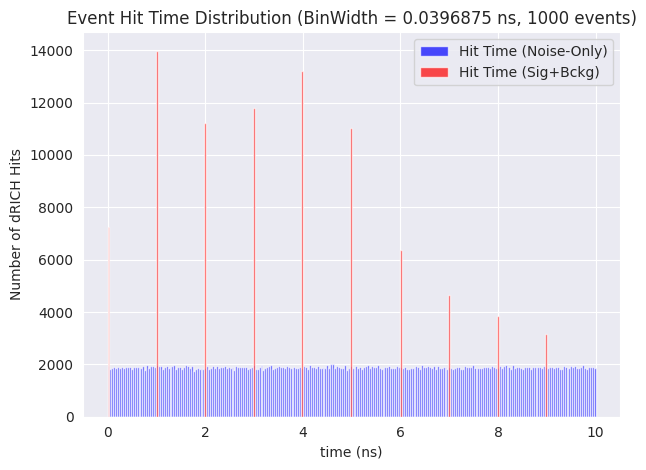

In [ ]:
fig, ax = plt.subplots(figsize=(10,7))

ax.grid(True)

a = df_time_noise["time"]
#b = (df_time_events["time"]*16)-(((df_time_events["time"]*16)//10.16)*10.16)
#  questo era quello orginale 2/2                          b = df_rec_signal_list[0]["time"]/16#(df_rec_signal_list[0]["time"]/16)-(((df_rec_signal_list[0]["time"]/16)//20.32)*20.32)
b = df_rec_signal_list[0]["time"]
print(sig_times)
print(b)


e = df_time_events["event"].max()
print(a.size)
print(b.size)

#bins = np.histogram(np.hstack((a,b)), bins=50)[1]
for exp in range(7):
    BIN_MIN = 0
    DCR = 300 #kHz
    BIN_MAX = 10
    BIN_WIDTH = 2.54/pow(2,exp)

    bins = np.arange(BIN_MIN, BIN_MAX + BIN_WIDTH, BIN_WIDTH)
    nbins = len(bins) - 1

    print(bins)
    n1, bins1, _ = plt.hist(a, bins=bins, alpha=0.7, label='Hit Time (Noise-Only)', color='blue')
    n0, bins0, _ = plt.hist(sig_times, bins=bins, alpha=0.7, label='Hit Time (Sig+Bckg)', color='red',)



    # Calcola integrali degli istogrammi
    print("Set di estremi dei bin utilizzati")
    print(bins0)
    print(n1)
    print(n1.mean()/e)

    integrale_noise = np.sum(n0)# * np.diff(bins))*len(bins)
    integrale_noise1 = np.sum(n1)# * np.diff(bins))*len(bins)
    # Stampa risultati
    print(f"Integrale Signal: {integrale_noise}")
    print(f"Integrale Noise: {integrale_noise1}")

    ax.set_yscale('log')
    #ax.set_xscale('log')
    ax.set_ylim(1,1.5*max([max(n0),max(n1)]))

    plt.xlabel('time (ns)')
    plt.ylabel('Number of dRICH Hits')
    plt.title(f'Event Hit Time Distribution (BinWidth = {BIN_WIDTH} ns, 1000 events)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    out = f"{OUTDIR}/histogram_dcr{DCR}kHz_Bin{BIN_WIDTH}ns.png"
    plt.savefig(out, dpi=200)
    print("Salvato:", out)


    plt.show()

In [ ]:
import os
import pandas as pd
import numpy as np
import time

nfiles = 582
df_sim_signal_list = []
df_index = 0
new_file_init = True

start = time.perf_counter()
print(f"SIMULATION DATASET")
for f in range(nfiles):
    print(f"SIGNAL FILE n.{f}")

    file_string = f"Bkg_1SignalPer2usframe_2601/sim_parts_{f+1:04d}.csv"

    if not os.path.exists(file_string):
        print(file_string + " skipped!")
        continue

    # Leggi CSV
    df_sim_signal = pd.read_csv(file_string, sep=',')

    # Salta DataFrame vuoti o senza colonna "event"
    if df_sim_signal.empty or "event" not in df_sim_signal.columns:
        continue

    # Riallinea eventi locali partendo da 0
    df_sim_signal["event"] = df_sim_signal.groupby("event", sort=False).ngroup()

    # Converte a intero per sicurezza
    df_sim_signal["event"] = df_sim_signal["event"].astype(int)

    nevents = df_sim_signal["event"].max()

    if new_file_init:
        # Split se supera 999
        if nevents > 999:
            df1 = df_sim_signal[df_sim_signal["event"] <= 999].copy()
            df2 = df_sim_signal[df_sim_signal["event"] > 999].copy()

            if not df2.empty:
                df2["event"] = (df2["event"] - df2["event"].min()) % 1000
                df2["event"] = df2["event"].astype(int)

            df_sim_signal_list.append(df1)
            df_index += 1
            df_sim_signal_list.append(df2)
        else:
            df_sim_signal_list.append(df_rec_signal)
        new_file_init = False
    else:
        # Offset globale rispetto al precedente, modulo 1000 per wrap
        df_previous = df_sim_signal_list[df_index]
        prev_max = df_previous["event"].max() if not df_previous.empty else -1
        df_sim_signal["event"] = (df_sim_signal["event"] + prev_max + 1)# % 1000
        df_sim_signal["event"] = df_sim_signal["event"].astype(int)

        # Concatenate temporanea
        df_conc = pd.concat([df_previous, df_sim_signal], ignore_index=True)
        nev = df_conc["event"].max()

        if nev > 999:
            df1 = df_conc[df_conc["event"] <= 999].copy()
            df2 = df_conc[df_conc["event"] > 999].copy()

            if not df2.empty:
                df2["event"] = (df2["event"] - df2["event"].min()) % 1000
                df2["event"] = df2["event"].astype(int)

            df_sim_signal_list[df_index] = df1
            df_index += 1
            df_sim_signal_list.append(df2)
            new_file_init = False
        else:
            df_sim_signal_list[df_index] = df_conc
            if nev == 999:
                new_file_init = True

end = time.perf_counter()
print(f"Tempo totale merging SIG+NOISE: {end - start:.4f}s")

SIMULATION DATASET
SIGNAL FILE n.0
SIGNAL FILE n.1
SIGNAL FILE n.2
SIGNAL FILE n.3
SIGNAL FILE n.4
Bkg_1SignalPer2usframe_2601/sim_parts_0005.csv skipped!
SIGNAL FILE n.5
SIGNAL FILE n.6
SIGNAL FILE n.7
SIGNAL FILE n.8
SIGNAL FILE n.9
SIGNAL FILE n.10
SIGNAL FILE n.11
SIGNAL FILE n.12
SIGNAL FILE n.13
SIGNAL FILE n.14
SIGNAL FILE n.15
Bkg_1SignalPer2usframe_2601/sim_parts_0016.csv skipped!
SIGNAL FILE n.16
SIGNAL FILE n.17
SIGNAL FILE n.18
Bkg_1SignalPer2usframe_2601/sim_parts_0019.csv skipped!
SIGNAL FILE n.19
SIGNAL FILE n.20
SIGNAL FILE n.21
SIGNAL FILE n.22
SIGNAL FILE n.23
Bkg_1SignalPer2usframe_2601/sim_parts_0024.csv skipped!
SIGNAL FILE n.24
SIGNAL FILE n.25
SIGNAL FILE n.26
Bkg_1SignalPer2usframe_2601/sim_parts_0027.csv skipped!
SIGNAL FILE n.27
SIGNAL FILE n.28
SIGNAL FILE n.29
SIGNAL FILE n.30
SIGNAL FILE n.31
SIGNAL FILE n.32
SIGNAL FILE n.33
SIGNAL FILE n.34
SIGNAL FILE n.35
Bkg_1SignalPer2usframe_2601/sim_parts_0036.csv skipped!
SIGNAL FILE n.36
SIGNAL FILE n.37
SIGNAL FI

In [ ]:
print(len(df_rec_signal_list))
print(len(df_sim_signal_list))

#print(df_rec_signal_list[88])

#tutti i """"file"""

88
92


      event           cell_id  sector   time  charge  pindex          gx  \
3084     42  1970350632368760       2  16150     302   54571  -99.826340   
3085     42  1125929997204088       2  16150     288   54571  -99.557945   
3086     42  1688871343899512       3  16150     366   54571 -104.709023   
3087     42  1125917095506552       2  16150     311   54571 -103.401085   
3088     42   844433528861304       2  16150     278   54571 -102.789978   
...     ...               ...     ...    ...     ...     ...         ...   
3479     42  1970354910343544       1  16157     265   54571  -11.510570   
3480     42  1688875630199160       1  16158     284   54572  -12.203633   
3481     42       12893608312       1  16158     289   54571   -0.201059   
3482     42   281474977063544       2  16158     290   54571 -106.434029   
3483     42  1125908505381496       2  16159     298   53185 -122.986771   

              gy          gz   lx   ly  pdu  sipm  xi  yi  
3084   57.554184  224.78233

/tmp/ipykernel_2314608/393618661.py:45: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.scatterplot(


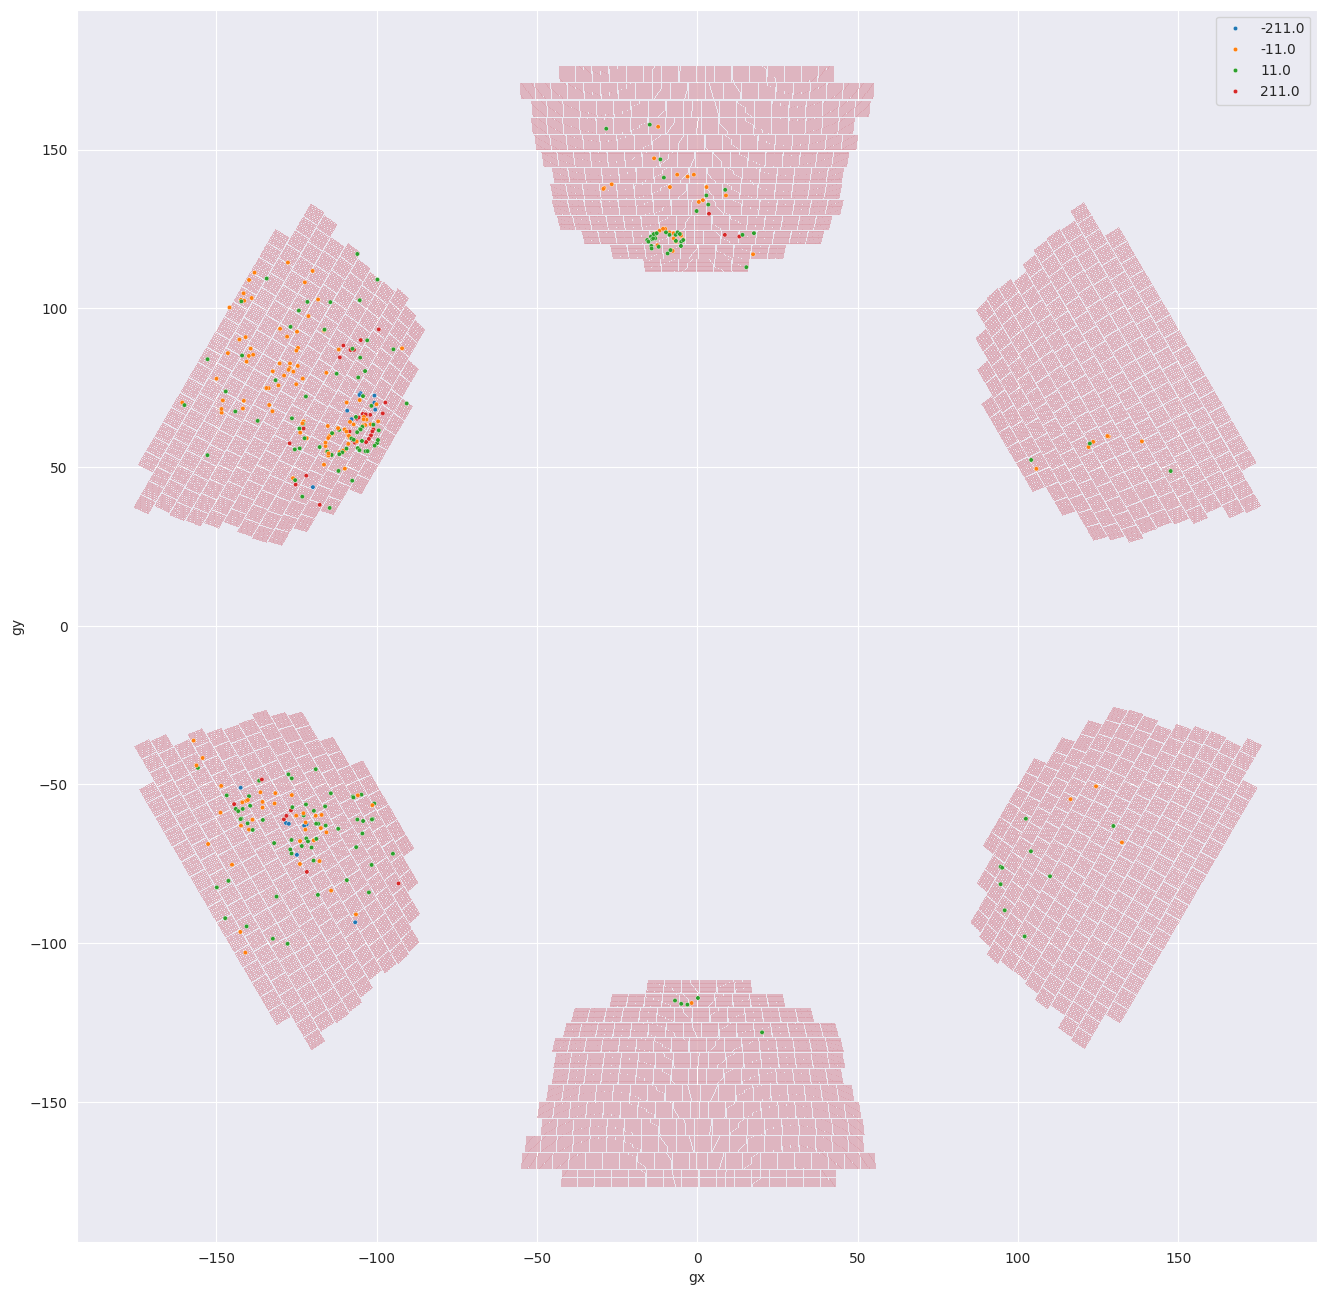

In [ ]:
# Plot entire dRICH + hits from event 15 in the EIC global coordinate system.
plt.figure(figsize=(16, 16))
global2d_plotcells(df_cellmap)


id_event = 42
id_file = 2
id1="" if id_file>10 else "0"
id2="" if id_file>100 else "0"
id3="" if id_file>1000 else "0"
#df_rec_last     = pd.read_csv(f"Bkg_1SignalPer2usframe_2601/rec_hits_{id3}{id2}{id1}{id_file}.csv", sep = ',')
df_rec_last     = pd.read_csv(f"Bkg_new/rec_new_{id3}{id2}{id1}{id_file}.csv", sep = ',')
df_sim_last     = pd.read_csv(f"Bkg_1SignalPer2usframe_2601/sim_parts_{id3}{id2}{id1}{id_file}.csv", sep = ',')
df_rec_show = df_rec_last
df_sim_show = df_sim_last

df_rec_show = df_rec_last
df_sim_show = df_sim_last

rf = df_rec_show[df_rec_show["event"] == id_event]
sf = df_sim_show[df_sim_show["event"] == id_event]
print(rf)
print(sf)

#global2d_plothits_timing(df_rec_last, 0)
global2d_plothits_tag(df_rec_show, df_sim_show, id_event)
plt.show()

In [ ]:
# ROBA NUOVA
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
# ROBA NUOVA

In [ ]:
def global2d_plothits_tag_v(df, tf, ei):
    df = df[df["event"] == ei]
    tf = tf[tf["event"] == ei]
    massimo=max(df["time"])
    minimo=min(df["time"])
    t_tot=[]
    x_tot=[]
    y_tot=[]
    hue_tot=[]
    for t in df["time"].unique():
        x_a=[]
        y_a=[]
        dfi = df[df["time"] == t]
        hue_a=[]
        for idx, row in dfi.iterrows():
            x_a.append(row["gx"])
            y_a.append(row["gy"])
            if(row["pindex"]==0):
                #print("NOISE")
                hue_a.append(0)
            else:
                for idx_t, row_t in tf.iterrows():
                    if(row["pindex"]==row_t["pindex"]):
                        #print("MATCH!")
                        hue_a.append(row_t["pdg"])
                        #print(row_t["pdg"])
                        break
        t_tot.append(t)
        x_tot.append(x_a)
        y_tot.append(y_a)
        hue_tot.append(hue_a)
    #print(np.asarray(x_tot).shape)
    #print(np.asarray(y_tot).shape)
    #print(np.asarray(hue_tot).shape)
    return t_tot,x_tot,y_tot,hue_tot
    #sns.scatterplot(
    #    x = x_a, y = y_a,
    #    s = 10, hue = hue_a, palette =  sns.color_palette()
    #)


In [ ]:
def plot_(x_a,y_a,hue_a):
    sns.scatterplot(
        x = x_a, y = y_a,
        s = 10, hue = hue_a, palette =  sns.color_palette()
    )

FILE #2
EVENT #42
START


#:	0		t:	16150 ns		#hits:	7


/tmp/ipykernel_2314608/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (1), which may not be intended.
  sns.scatterplot(


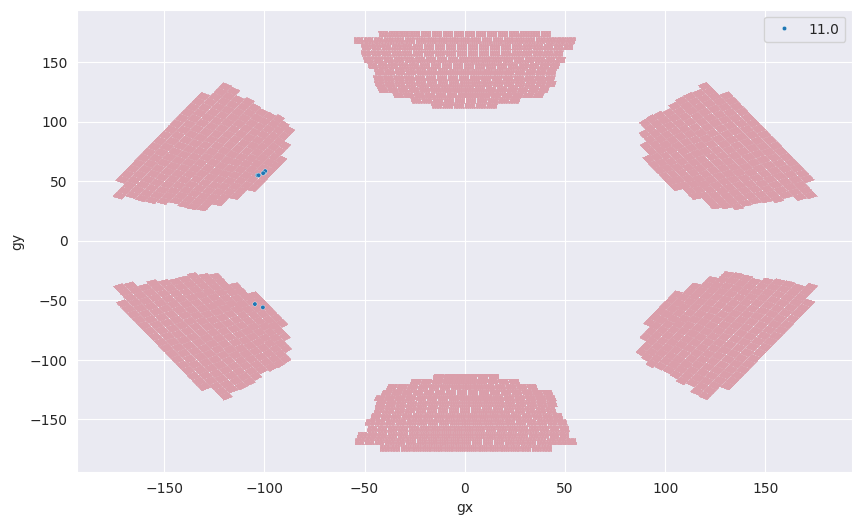

#:	1		t:	16151 ns		#hits:	142


/tmp/ipykernel_2314608/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.scatterplot(


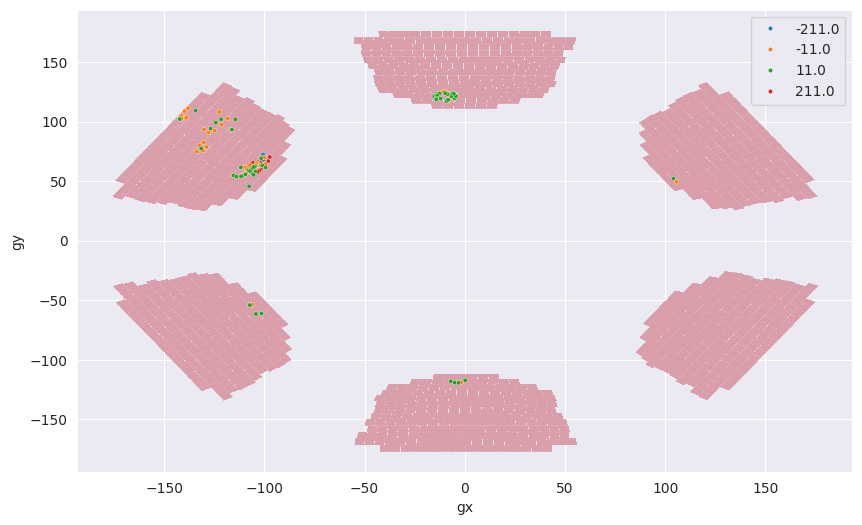

#:	2		t:	16152 ns		#hits:	70


/tmp/ipykernel_2314608/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.scatterplot(


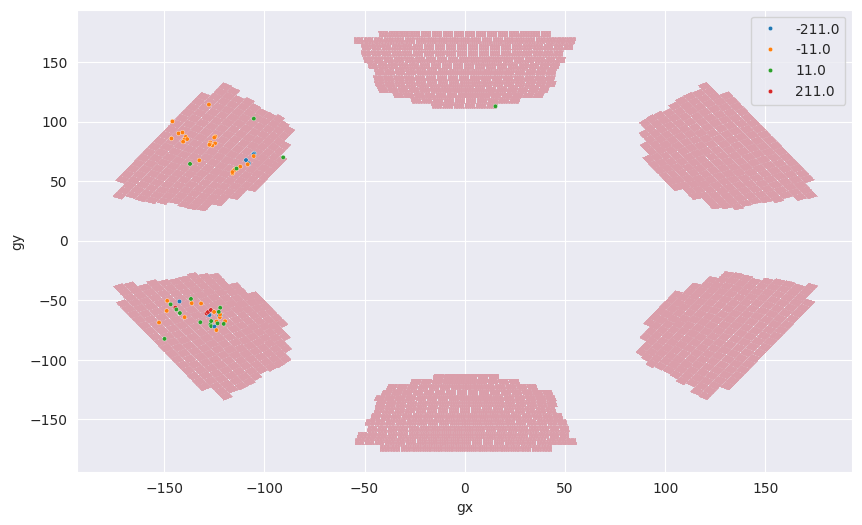

#:	3		t:	16153 ns		#hits:	35


/tmp/ipykernel_2314608/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.scatterplot(


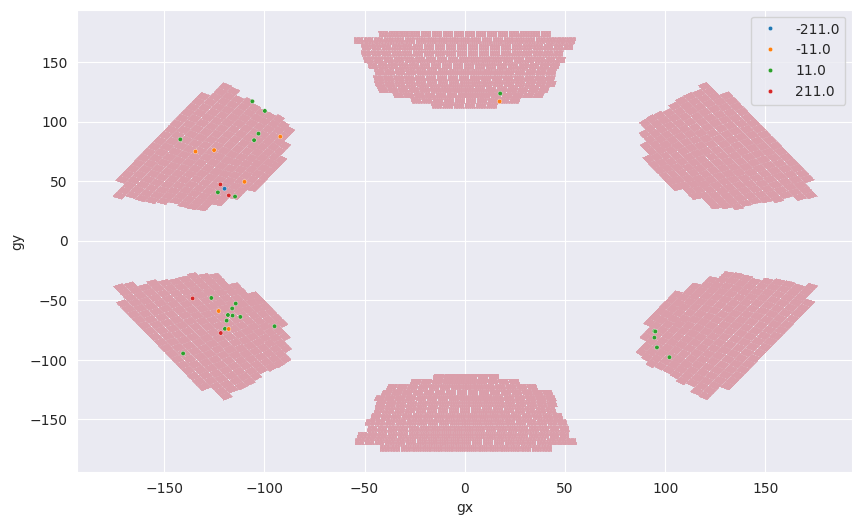

#:	4		t:	16154 ns		#hits:	59


/tmp/ipykernel_2314608/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(


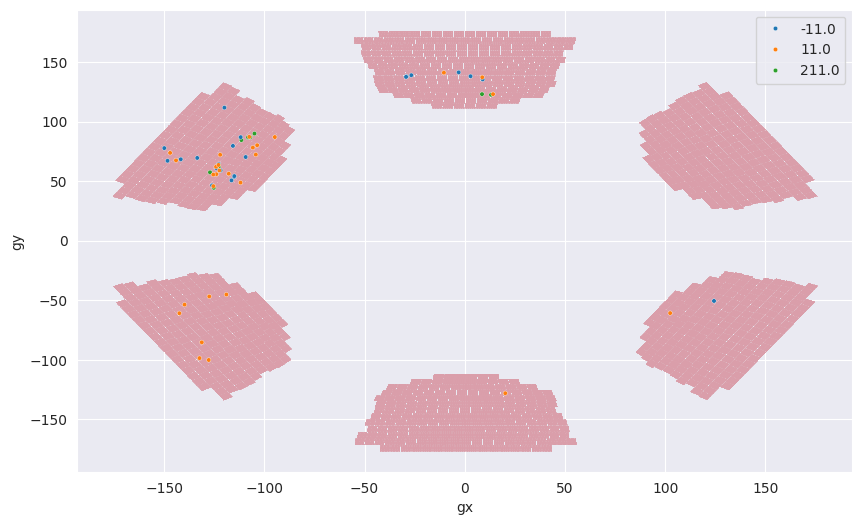

#:	5		t:	16155 ns		#hits:	47


/tmp/ipykernel_2314608/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(


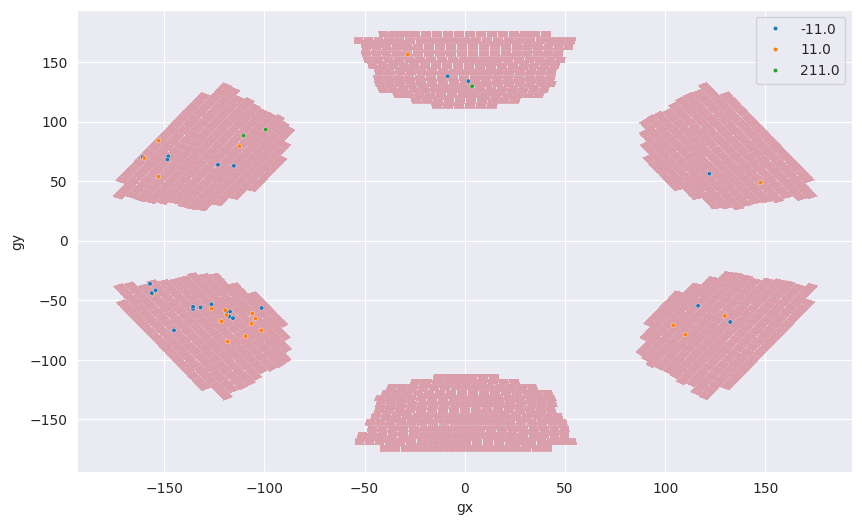

#:	6		t:	16156 ns		#hits:	27


/tmp/ipykernel_2314608/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(


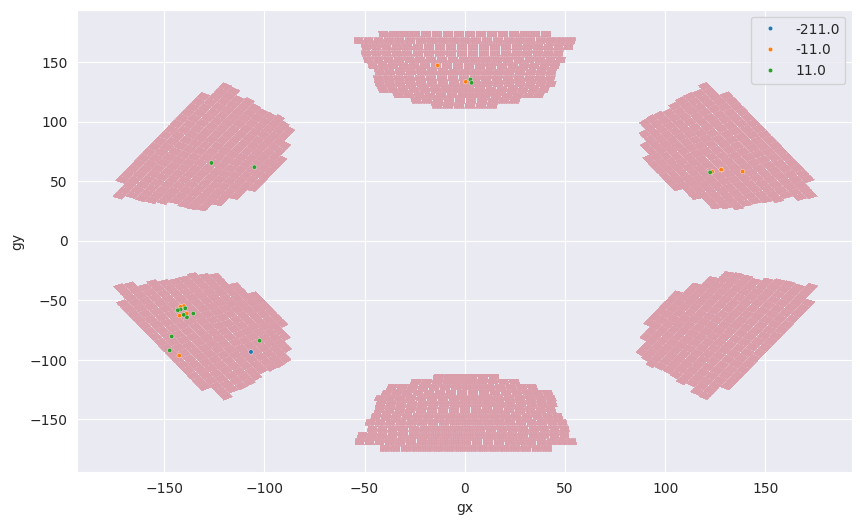

#:	7		t:	16157 ns		#hits:	9


/tmp/ipykernel_2314608/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(


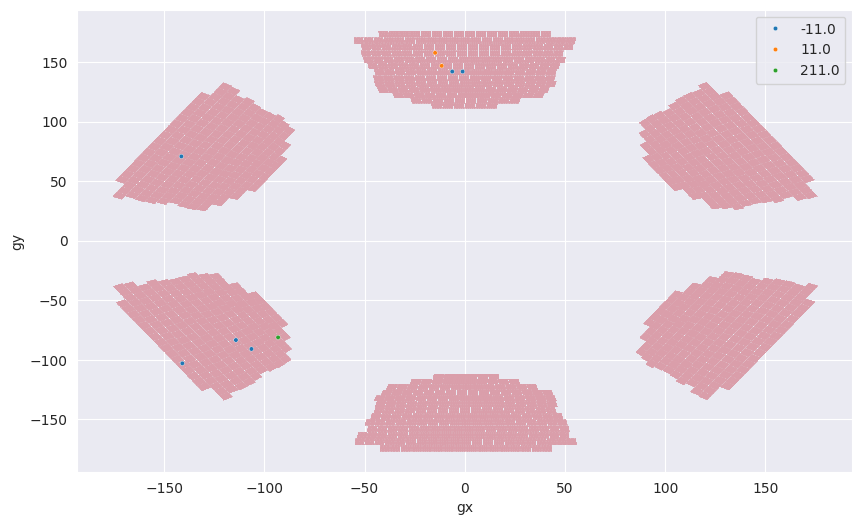

#:	8		t:	16158 ns		#hits:	3


/tmp/ipykernel_2314608/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.scatterplot(


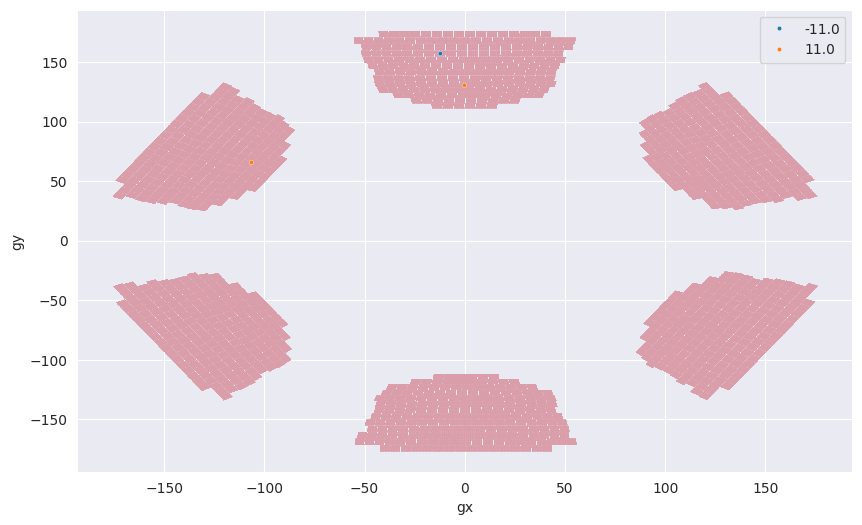

#:	9		t:	16159 ns		#hits:	1


/tmp/ipykernel_2314608/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (1), which may not be intended.
  sns.scatterplot(


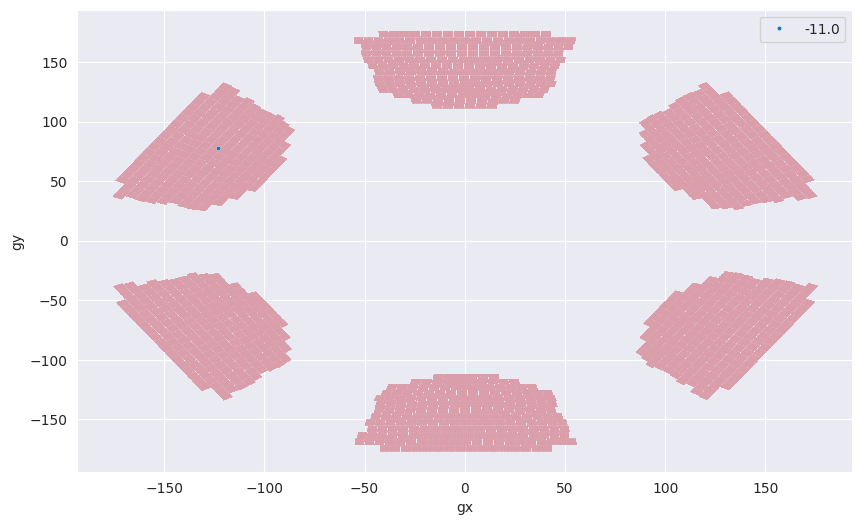

In [ ]:
# Plot entire dRICH + hits from event 15 in the EIC global coordinate system.

id_event = 42
id_file = 2
id1="" if id_file>10 else "0"
id2="" if id_file>100 else "0"
id3="" if id_file>1000 else "0"
df_rec_last     = pd.read_csv(f"Bkg_new/rec_new_{id3}{id2}{id1}{id_file}.csv", sep = ',')
df_sim_last     = pd.read_csv(f"Bkg_1SignalPer2usframe_2601/sim_parts_{id3}{id2}{id1}{id_file}.csv", sep = ',')
df_rec_show = df_rec_last
df_sim_show = df_sim_last

rf = df_rec_show[df_rec_show["event"] == id_event]
sf = df_sim_show[df_sim_show["event"] == id_event]


T,X,Y,HUE=global2d_plothits_tag_v(df_rec_show, df_sim_show, id_event)

print(f"FILE #{id_file}\nEVENT #{id_event}\nSTART\n\n")
for i in range(len(T)):
    plt.figure(figsize=(10,6))
    global2d_plotcells(df_cellmap)
    print(f"#:\t{i}\t\tt:\t{T[i]} ns\t\t#hits:\t{len(X[i])}")
    plot_(X[i],Y[i],HUE[i])
    plt.show()

In [ ]:
def global2d_plothits_tag_bin(df, tf, ei):
    df = df[df["event"] == ei]
    tf = tf[tf["event"] == ei]
    massimo=max(df["time"])
    minimo=min(df["time"])
    t_tot=[]
    x_tot=[]
    y_tot=[]
    hue_tot=[]
    for t in np.linspace(minimo,massimo,5):#df["time"].unique():
        if t==massimo:
            break
        x_a=[]
        y_a=[]
        dfi = df[df["time"] >= t ]
        dfi = dfi[dfi["time"] < (t+(massimo-minimo)/4) ]
        hue_a=[]
        for idx, row in dfi.iterrows():
            x_a.append(row["gx"])
            y_a.append(row["gy"])
            if(row["pindex"]==0):
                #print("NOISE")
                hue_a.append(0)
            else:
                for idx_t, row_t in tf.iterrows():
                    if(row["pindex"]==row_t["pindex"]):
                        #print("MATCH!")
                        hue_a.append(row_t["pdg"])
                        #print(row_t["pdg"])
                        break
        t_tot.append(t)
        x_tot.append(x_a)
        y_tot.append(y_a)
        hue_tot.append(hue_a)
    #print(np.asarray(x_tot).shape)
    #print(np.asarray(y_tot).shape)
    #print(np.asarray(hue_tot).shape)
    return t_tot,x_tot,y_tot,hue_tot
    #sns.scatterplot(
    #    x = x_a, y = y_a,
    #    s = 10, hue = hue_a, palette =  sns.color_palette()
    #)


FILE #2
EVENT #42
START


#:	0		t:	16150.0 ns		#hits:	219


/tmp/ipykernel_2314608/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.scatterplot(


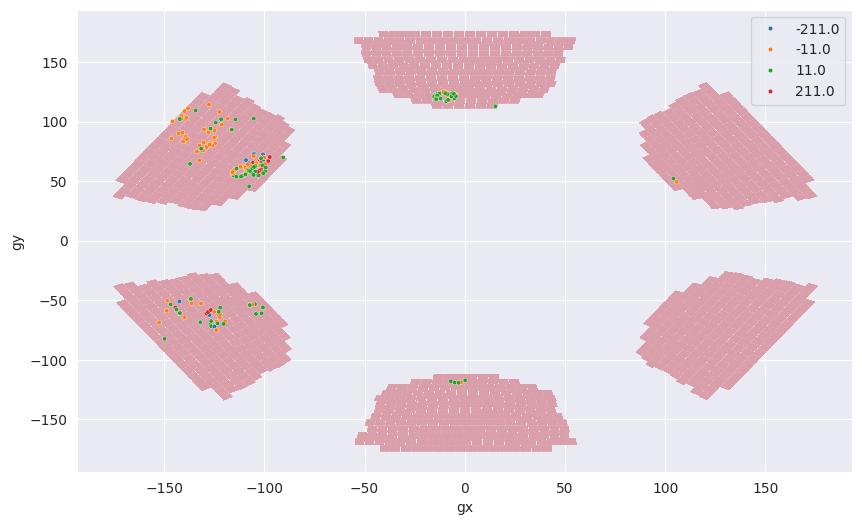

#:	1		t:	16152.25 ns		#hits:	94


/tmp/ipykernel_2314608/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.scatterplot(


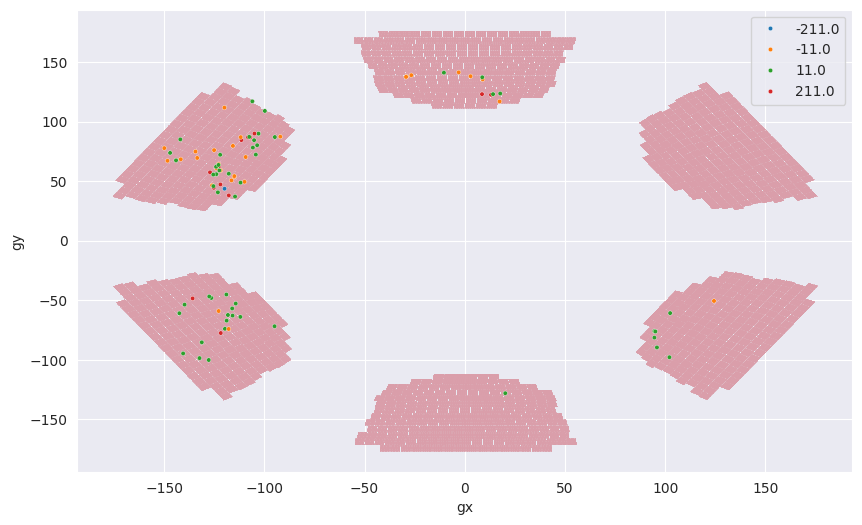

#:	2		t:	16154.5 ns		#hits:	74


/tmp/ipykernel_2314608/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.scatterplot(


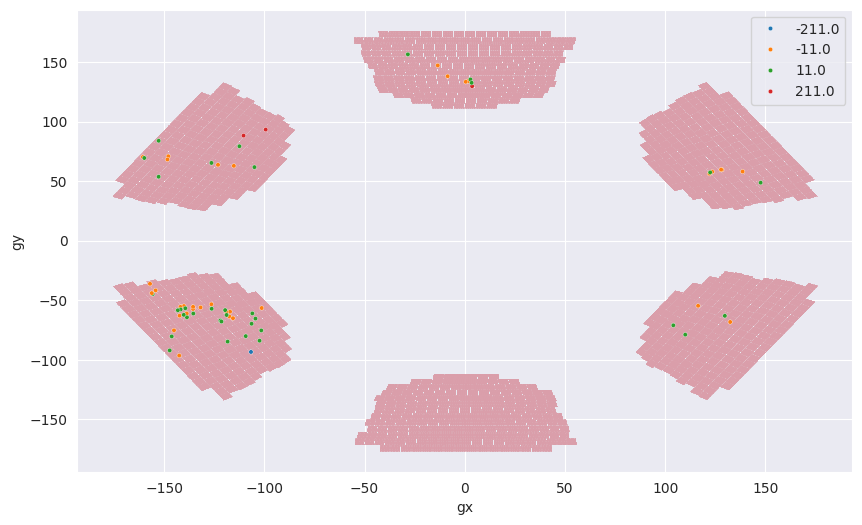

#:	3		t:	16156.75 ns		#hits:	12


/tmp/ipykernel_2314608/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(


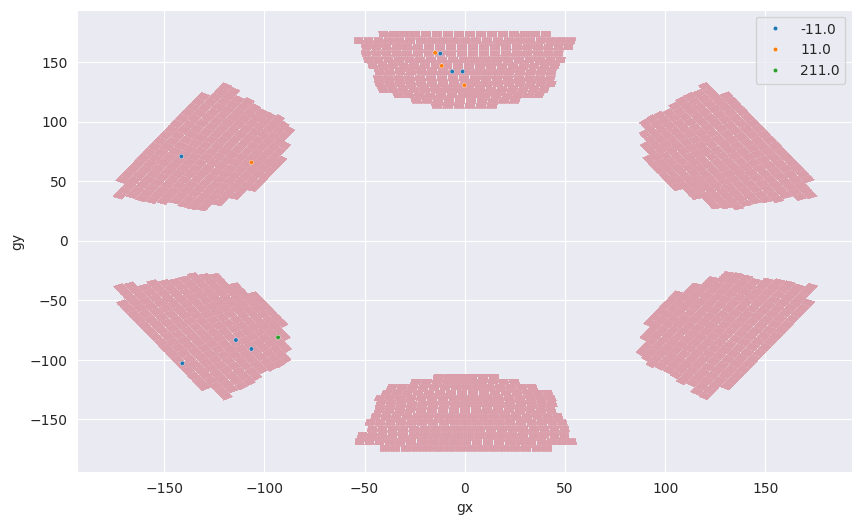

In [ ]:
# Plot entire dRICH + hits from event 15 in the EIC global coordinate system.

id_event = 42
id_file = 2
id1="" if id_file>10 else "0"
id2="" if id_file>100 else "0"
id3="" if id_file>1000 else "0"
df_rec_last     = pd.read_csv(f"Bkg_new/rec_new_{id3}{id2}{id1}{id_file}.csv", sep = ',')
df_sim_last     = pd.read_csv(f"Bkg_1SignalPer2usframe_2601/sim_parts_{id3}{id2}{id1}{id_file}.csv", sep = ',')
df_rec_show = df_rec_last
df_sim_show = df_sim_last

rf = df_rec_show[df_rec_show["event"] == id_event]
sf = df_sim_show[df_sim_show["event"] == id_event]


T,X,Y,HUE=global2d_plothits_tag_bin(df_rec_show, df_sim_show, id_event)

print(f"FILE #{id_file}\nEVENT #{id_event}\nSTART\n\n")
for i in range(len(T)):
    plt.figure(figsize=(10,6))
    global2d_plotcells(df_cellmap)
    print(f"#:\t{i}\t\tt:\t{T[i]} ns\t\t#hits:\t{len(X[i])}")
    plot_(X[i],Y[i],HUE[i])
    plt.show()